# [Bacterial Colony Growth](@id Bacteries)

In this example, we are going to create a bacterial model and grow a colony using it.

 - The implementation of the force interaction dynamics is the one presented by [Volfson et al. (2008)](https://www.pnas.org/doi/abs/10.1073/pnas.0706805105)
 - We use GPU accelerated dynamics

As described in other models, it is advised that the models are constructed by parts to avoid having to find bugs in a very complex system. Hence, we will split the model in two parts:

 - Forces model
 - Growth model

## Load the packages

In [84]:
using Base.Threads
println("Usando ", nthreads(), " threads 😎")

Usando 1 threads 😎


In [85]:
# import Pkg
# Pkg.activate("../")
# Pkg.instantiate()


In [86]:
# import Pkg; Pkg.add(["Revise", "GLMakie"])

In [87]:
# using Revise
# using CellBasedModels
# using CUDA
# using Distributions
# using GLMakie
# # using GeometryBasics
# import GLMakie: Point3f, Cylinder, Sphere, NoShading #Can be changes to Cairo or CLMakie

In [88]:
import Pkg

# Activa el entorno del proyecto
Pkg.activate("../../../../")


# Resuelve y asegura dependencias
Pkg.resolve()
Pkg.instantiate()


# Carga los paquetes de forma ordenada
using Revise
using CellBasedModels
ENV["JULIA_CUDA_USE_BINARYBUILDER"] = false  # (opcional, fuerza compilación local)
using CUDA
CUDA.set_runtime_version!(v"12.2")
using Distributions
using CairoMakie
using JSON

# Importa funciones específicas después
import CairoMakie: Point3f, Cylinder, Sphere, NoShading

CairoMakie.activate!()


  Activating project at `~/Escritorio/Projects/Pushing/ABM_CBM`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Project.toml`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Manifest.toml`
┌ Info: Configure the active project to use CUDA 12.2; please re-start Julia for this to take effect.
└ @ CUDA /home/julia/.julia/packages/CUDA/jdJ7Z/lib/cudadrv/version.jl:82


## Forces model

We already use the defined forces model that is implemented in CBqodels. This is an exact copy of the rod model that you can find already predefined in `Models/rods.jl`. You can check the `Models` section of the documentation for more details.


In [89]:
rod2D = ABM(2,
    agent = Dict(
            :theta=>Float64,
            :d=>Float64,
            :l=>Float64,
            :fx=>Float64,
            :fy=>Float64,
            :W=>Float64,
        ),    #Local Interaction Parameters

    model = Dict(
            :E=>Float64,
            :eta=>Float64,
        ),        #Global parameters

    agentODE = quote

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin

            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij

            
        end

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=GPU(),
    agentAlg = CBMIntegrators.Heun()
);


### Initialize a coqunity with two bacteries and check forces

In [90]:
com = Community(rod2D,
            N=30,
            dt=1.,
            simBox = [-10 10;-10 10.],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=100. *m/(t^2*d)*1.E-3 #kPa
com.eta=500 *m/(t*d) #Pa h

com.d = 1.        
com.l = 3.99      



com.x = 0
com.y = 0
com.theta = 0;


In [91]:
for i in 1:com.N
    com.theta[i] = rand() * 2π
    com.x[i] = rand()*16-8
    com.y[i] = rand()*16-8
    com.l[i] = 3.0
    com.d[i] = 1.0

end

In [92]:
evolve!(com,steps=10000,saveEach=100,preallocateAgents=com.N)

In [93]:
function plotAgents2D!(ax, x, y, d, l, angle, p; colormap=:inferno, kargs...)
    for (xi, yi, li, di, ai, pi) in zip(x, y, l, d, angle, p)



            colorval = pi
            # colormap = :inferno
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [colorval],
                colormap = colormap,
                kargs...
            )

    end
    return
end


plotAgents2D! (generic function with 1 method)

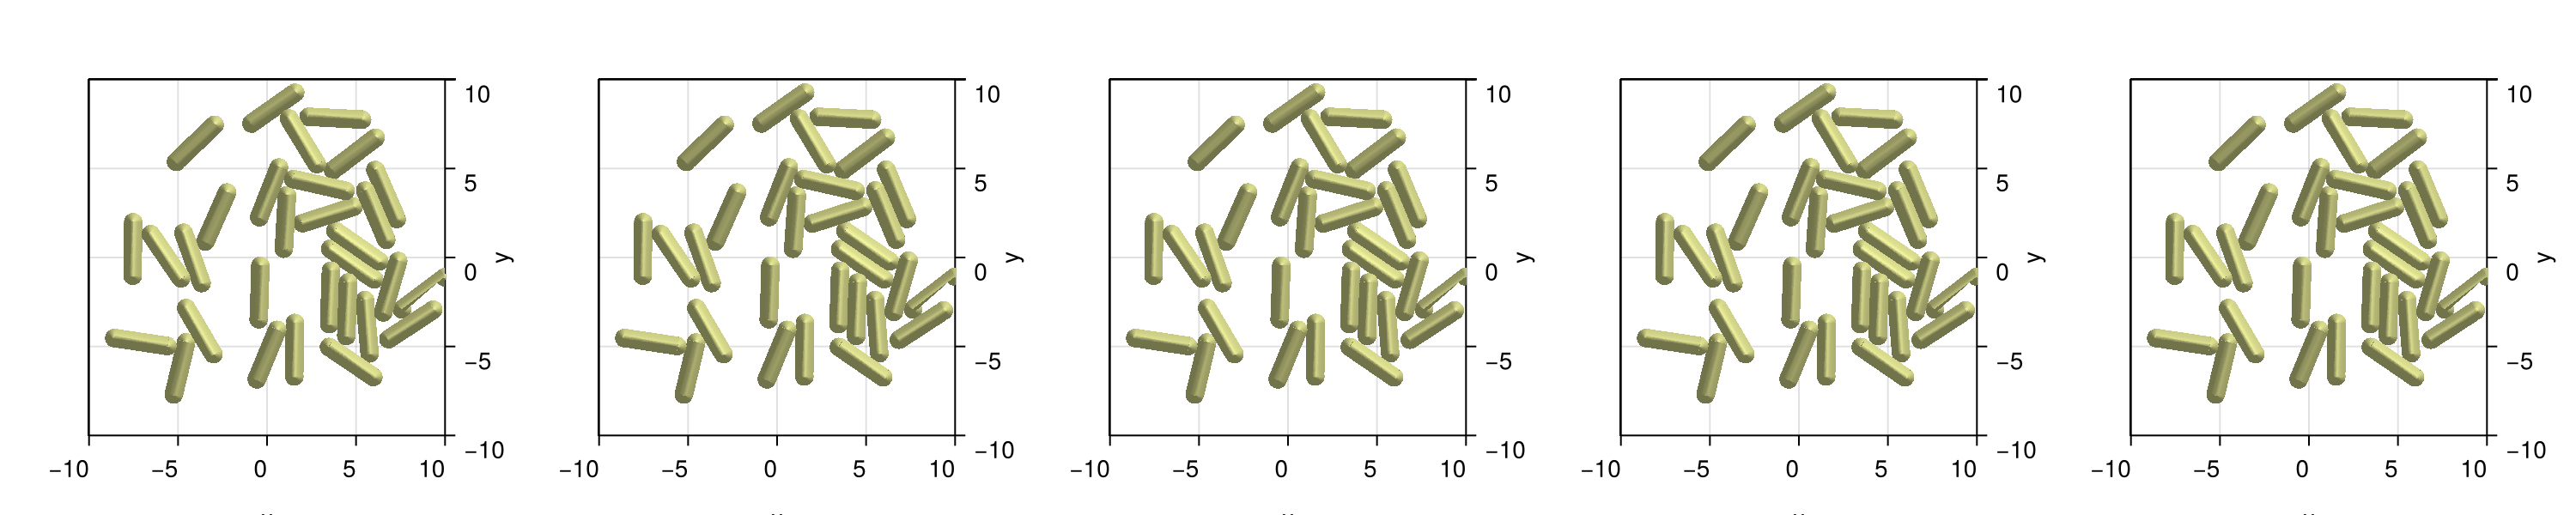

CairoMakie.Screen{IMAGE}


In [94]:
fig = Figure(size=(1500,300))

for (i,j) in enumerate([1:round(Int,length(com)/4):length(com);length(com)])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com[j][:x],
    com[j][:y],
    com[j][:d],
    com[j][:l],
    com[j][:theta],
    com[j][:l],
    colorrange = (0, maximum(com.l))
)

    xlims!(-10,10)
    ylims!(-10,10)
end

display(fig)

In [95]:

function log_community_state(parameters::OrderedDict, t::Int, path::String = "parameters_QS_cap.txt")
    # Convert keys to strings so JSON can serialize them
    string_keys = Dict(string(k) => v for (k, v) in parameters)
    # Build entry
    entry = Dict("t" => t, "parameters" => string_keys)
    # Save as a JSON line
    open(path, "a") do io
        println(io, JSON.json(entry))
    end
end


function load_parameters_log(path::String = "parameters_QS_cap.txt")
    log = Dict{Int, OrderedDict{Symbol, Any}}()
    for line in eachline(path)
        entry = JSON.parse(line)
        t = entry["t"]
        raw_params = entry["parameters"]
        params = OrderedDict(Symbol(k) => v for (k, v) in raw_params)
        log[t] = params
    end
    times = sort(collect(keys(log)))
    com_array = [log[t] for t in times]
    return com_array, times
end



load_parameters_log (generic function with 2 methods)

## Growth model

We construct over the forces model to add bacterial growth and cell division rules.

In [96]:
rods2dGrowth = ABM(2,
    baseModelInit = [rod2D],

    agent = Dict(
                :dg=> Float64, 
                :lTarget => Float64,
                :type => Int,
                :Ki => Float64,
                :V => Float64,
                :Gi => Float64,
                :Rg => Float64,
                :nk => Float64,
                :S => Float64
            ),

    model = Dict(
                :growth=>Float64,
                :σlTarget=>Float64,
                :lMax=>Float64,
                :D_q => Float64,
                :delta_q => Float64,
                :alpha_q => Float64, 
                :beta_q => Float64,
                :K_q=>Float64,
                :alpha_H => Float64, 
                :K_qH=>Float64,
                :q_c=>Float64,
                :F => Float64,
                :gk => Float64,
                :gL => Float64,
                :gv => Float64,
                :Vk0 => Float64,
                :VL => Float64,
                :Km => Float64,
                :alpha_Ke=> Float64,
                :Dp=> Float64,
                :alpha_n => Float64,
                :K_n => Float64,
                :delta_n => Float64,
                :gamma_H => Float64,
                :alpha_PGA => Float64,
                :alpha_P2 => Float64,
                :alpha_dg => Float64,
                :K_g => Float64,
                :alpha_g => Float64,
                :delta_g => Float64,
                :alpha_R => Float64,
                :delta_R => Float64,
                :beta_R => Float64,
                :K_R => Float64,
                :S0 => Float64,
                :K_S => Float64,
                :delta_s => Float64,
                :D_PGA => Float64,
                :D_H => Float64,
                :D_Ge => Float64,
                :K_Ge => Float64,
                :Ki0 => Float64,
            ),
    
    medium = Dict(
        :Ge => Float64,        #nutrient field
        :q => Float64,        #Qs field
        :Ke => Float64,        #External K+ field
        :H => Float64,        #Hydrogel field
        :P2 => Float64,        #PGA polymer field
        :PGA => Float64,        #PGA field
    ),

 
    agentODE = quote    
        Vk=Vk0*log(Ke/Ki)
        FV = 1/(1+exp(gv*(V-VL)))
        dt(l) = l*growth*Gi/(1+Gi) #linear growth with growth dependent on the pressure over the cell
        dt(Gi) = alpha_g*FV*Rg*Ge/(K_g+Ge)-delta_g*Gi #linear growth with growth dependent on the pressure over the cell
        dt(Rg) = alpha_R - delta_R*Rg + beta_R*Gi^2/(K_R^2+Gi^2) #linear growth with growth dependent on the pressure over the cell
        dt(Ki) = -F*gk*nk^4*(V-Vk)+Dp*Gi*Ke*(Ki0-Ki)
        dt(V) = -gk*nk^4*(V-Vk)-gL*(V-VL)
        dt(S) = S0 /(1 + (Gi/K_S)^2)-delta_s*S
        dt(nk) = alpha_n*S/(K_n + S)-delta_n*nk 

        dg =  alpha_dg * H 

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin
            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,dg+d,l,theta,
                                    x[i2],y[i2],dg[i2]+d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij

            
        end
        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    agentRule = quote #Bound cells
        Vk=Vk0*log(Ke/Ki)
        FV = 1/(1+exp(gv*(V-VL)))


        #Add division
        if l > lTarget
            ww = CBMDistributions.uniform(-1,1)*1.E-2 #To add some random torque at division time

            # ww = 0 #To add some random torque at division time
            #Add a new cell
            @addAgent(
                    x=(l+d)/4*cos(theta)+x,
                    y=(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    W=ww,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget),
                    dg=sqrt((l-d)^2+dg^2+4*dg*l)-(l-d))
            #Add a second cell
            @addAgent(
                    x=-(l+d)/4*cos(theta)+x,
                    y=-(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget), #New target length at which the bactery should divide
                    W=ww,
                    dg=sqrt((l-d)^2+dg^2+4*dg*l)-(l-d))
            #Remove the old cell
            @removeAgent()
        end
        # Probability of releasing qs with a saturating function
        
        q += (alpha_q + beta_q*q^4/(K_q^4 + q^4))*dt
        Ke += (F*gk*nk^4*(V-Vk)- Dp*Gi*Ke)*dt
        # PGA += (alpha_PGA*K_qH^4/(K_qH^4+(q-q_c)^4))*dt
        Ge += (-alpha_g*FV*Rg*Ge/(K_Ge+Ge))*dt
        

    end,

    #Medium dynamics with dirichlet conditions and a wall that is as oscillating source of material
    mediumODE=quote 
        if @mediumInside()
            dt(Ge) = D_Ge*(@∂2(1,Ge)+@∂2(2,Ge)) 
            dt(q) = D_q*(@∂2(1,q)+@∂2(2,q)) - delta_q*q 
            #dt(Ke) = D_k*(@∂2(1,Ke)+@∂2(2,Ke)) 
            dt(Ke) = -alpha_Ke*(Ke-Km) - gamma_H*Ke*H
            # dt(PGA) = alpha_P2*PGA + D_PGA*(@∂2(1,q)+@∂2(2,q))
            # dt(P2) = -alpha_P2*PGA  + gamma_H*Ke*H 
        
            # dt(H) = +alpha_H*P2 - gamma_H*Ke*H + D_H*(@∂2(1,q)+@∂2(2,q))
            # dt(H) = +alpha_H*P2 - gamma_H*Ke*H

        elseif @mediumBorder(1,-1)
            q = 0
            Ke = Km
            PGA=0
            Ge = 30
            H=0
            P2=0
        elseif @mediumBorder(1,1)
            q = 0 
            Ke = Km
            PGA=0
            Ge = 30

            H=0
            P2=0
        elseif @mediumBorder(2,-1)
            q = 0
            Ke = Km
            PGA=0
            Ge = 30

            H=0
            P2=0
        elseif @mediumBorder(2,1)
            q = 0
            Ke = Km
            PGA=0
            Ge = 30

            H=0
            P2=0
        end

    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=CPU(),
    agentAlg=CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
);

In [97]:
function plotMixedAgents2D!(ax, x, y, d, l, angle, type, p; kargs...)
    for (xi, yi, li, di, ai, ti, pi) in zip(x, y, l, d, angle, type, p)


        if ti== 0  # rods
            # colorval = pi
            # colormap = :Blues
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:blue],
                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],

                color = [:blue],
                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [:blue],

                kargs...
            )
        else  # puntos
            colorval = pi
            colormap = :Reds
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:red],
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:red],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [:red],
                colormap = colormap,
                kargs...
            )
        end

    end
    return
end


plotMixedAgents2D! (generic function with 1 method)

## Grow colony from one cell

In [138]:
com = Community(rods2dGrowth,
            N=1,
            dt=0.0001,
            simBox = [-100 100;-100 100.],
            NMedium=[100,100],
            );

#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=6* 1.E5 *m/(t^2*d) #Pa
com.eta=150 *m/(t^2*d) #Pa h

# com.D_q = 1.E-11 *d^2/t #m^2/s
com.D_q = 50 #m^2/s
com.D_Ge = 50 #m^2/s
# com.D_Ke = 0.0 #m^2/s

com.alpha_q = 2 #nM /h
com.delta_q = 0.1 #1/h
com.beta_q = 10 #1/s
com.K_q = 1


com.dg=0.
com.alpha_PGA = 10.
com.K_qH = 1.
com.q_c = 20. 

com.alpha_P2=0
com.alpha_H=0
com.gamma_H=0

com.growth = 1.
com.lMax = 4.     
com.σlTarget = 1. 
 
com.d = 1.        
com.l = 3.99      
com.lTarget = 4.  
# com.v = 2.E-2 



com.alpha_n=91
com.K_n = 0.03
com.delta_n = 34


com.D_PGA =10
com.D_H = 1

com.x = 0
com.y = 0
com.theta = 0

com.Km = 8
com.Ke = com.Km
com.Dp = 0.12 #mM⁻2 h⁻1
com.Gi = 10 #mM
com.F = 0.05 #mM/mV
com.gk =70 #h⁻1
com.gL =18 #h⁻1
com.Vk0 = 100 #mV
com.VL = -156 #mV
com.nk = 0. 
com.alpha_Ke = 10       
com.Ki = 300 #mM
com.V = -150 #mM

com.alpha_g = 24 #mM h⁻1
com.K_g = 0.75
com.delta_g = 4.8

com.alpha_R = 4.5
com.delta_R = 24.
com.beta_R = 31.
com.K_R = 2.25
com.S0 = 1.12
com.K_S = 0.2
com.delta_s = 2.8
com.gv = 1.
com.K_Ge = 0.75
com.Ki0 = 300.

com.Ge = 30.
com.S=0

0

In [ ]:
steps=Int(round(8/com.dt))
# saveEach=steps/100
saveEach=Int(round(10/com.dt))/100
# steps=100000
# saveEach=10000
N=100 

loadToPlatform!(com,preallocateAgents=N)
open("parameters_QS_cap.txt", "w") do f
    # clear file at start
end

for step in 1:steps
    
    step!(com)
    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N <= 0
                println("Step ",step, " N: ", com.N, " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N  < 4*com.N
                N = 15*com.N
        end 
        println("Step ",step, " N: ", com.N)
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)


Step 1000 N: 2
Step 2000 N: 2
Step 3000 N: 2
Step 4000 N: 2
Step 5000 N: 2
Step 6000 N: 2
Step 7000 N: 2
Step 8000 N: 2
Step 9000 N: 2
Step 10000 N: 3
Step 11000 N: 3
Step 12000 N: 3
Step 13000 N: 4
Step 14000 N: 4
Step 15000 N: 4
Step 16000 N: 4
Step 17000 N: 4
Step 18000 N: 4
Step 19000 N: 4
Step 20000 N: 4
Step 21000 N: 4
Step 22000 N: 4
Step 23000 N: 4
Step 24000 N: 5
Step 25000 N: 5
Step 26000 N: 8
Step 27000 N: 8
Step 28000 N: 8
Step 29000 N: 8
Step 30000 N: 8
Step 31000 N: 8
Step 32000 N: 8
Step 33000 N: 8
Step 34000 N: 8
Step 35000 N: 8
Step 36000 N: 8
Step 37000 N: 8
Step 38000 N: 10
Step 39000 N: 10
Step 40000 N: 11
Step 41000 N: 12
Step 42000 N: 13
Step 43000 N: 15
Step 44000 N: 16
Step 45000 N: 16


In [ ]:
com_load,times=load_parameters_log("parameters_QS_cap.txt")


In [ ]:
com_load,times=load_parameters_log("parameters_QS_cap.txt")
colormap=:Oranges
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:Ge]), com_load)))
colormap_b=:Blues
colorrange_b = (0.0,  maximum(maximum(p -> maximum(p[:Gi]), com_load)))
fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
simBox_cpu = Array(com.simBox)  # copia a CPU


for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ge]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Gi],
    colorrange = colorrange_b,
    colormap = colormap_b,
    )

    xlims!(-20,20)
    ylims!(-20,20)
end

Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ge"
)
Colorbar(fig[1, length(js) + 2],
    colormap = colormap_b,
    colorrange = colorrange_b,
    label = "Gi"
)

display(fig)

In [ ]:
com_load,times=load_parameters_log("parameters_QS_cap.txt")
colormap=:Oranges
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:Ge]), com_load)))
colormap_b=:Blues
colorrange_b = (0.0,  maximum(maximum(p -> maximum(p[:S]), com_load)))
fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
simBox_cpu = Array(com.simBox)  # copia a CPU


for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ge]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:S],
    colorrange = colorrange_b,
    colormap = colormap_b,
    )

    xlims!(-20,20)
    ylims!(-20,20)
end

Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ge"
)
Colorbar(fig[1, length(js) + 2],
    colormap = colormap_b,
    colorrange = colorrange_b,
    label = "S"
)

display(fig)

In [ ]:
com_load,times=load_parameters_log("parameters_QS_cap.txt")
colormap=:Oranges
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
simBox_cpu = Array(com.simBox)  # copia a CPU


for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    


    xlims!(-50,50)
    ylims!(-50,50)
end

Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "QS"
)


display(fig)

In [ ]:
com_load,times=load_parameters_log("parameters_QS_cap.txt")
colormap=:Oranges
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
simBox_cpu = Array(com.simBox)  # copia a CPU


for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    


    xlims!(-50,50)
    ylims!(-50,50)
end

Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "PGA"
)


display(fig)

In [ ]:
com_load,times=load_parameters_log("parameters_QS_cap.txt")
colormap=:Oranges
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
simBox_cpu = Array(com.simBox)  # copia a CPU


for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:H]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:V],
    colorrange = (0, 0.03)
    )

    xlims!(-100,100)
    ylims!(-100,100)
end

display(fig)

In [ ]:
# Colormap común y colorrange fijo
colormap = :Oranges
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))
# colorrange = (0.0,  0.01)


simBox_cpu = Array(com.simBox)  # copia a CPU

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:dg],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:dg],
    # colormap=:Blues,
    # colorrange = colorrange
    # )

    xlims!(-50,50)
    ylims!(-50,50)
end


# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "QS"
)

display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))
colorrange_h = (0.0,  maximum(maximum(p -> maximum(p[:dg]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:dg],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-20,20)
    ylims!(-20,20)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "QS"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "H"
)
display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:V]), com_load)),  maximum(maximum(p -> maximum(p[:V]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:V],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-20,20)
    ylims!(-20,20)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "V"
    
)
display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:Ki]), com_load)),  maximum(maximum(p -> maximum(p[:Ki]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:Ki],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-20,20)
    ylims!(-20,20)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "Ki"
    
)
display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:pressure]), com_load)),  maximum(maximum(p -> maximum(p[:pressure]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:pressure],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-20,20)
    ylims!(-20,20)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "P"
    
)
display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:nk]), com_load)),  maximum(maximum(p -> maximum(p[:nk]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:nk],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-20,20)
    ylims!(-20,20)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "nk"
    
)
display(fig)

In [ ]:

colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:F] .*p[:gk] .* p[:nk].^4 ./ (p[:V] .- p[:Vk0])), com_load)),  maximum(maximum(p -> maximum(p[:F] .*p[:gk] .* p[:nk].^4 ./ (p[:V] .- p[:Vk0])), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:F] .*com_load[j][:gk] .* com_load[j][:nk].^4 ./ (com_load[j][:V] .- com_load[j][:Vk0]),
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-20,20)
    ylims!(-20,20)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "K_in_out"
    
)
display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:V]), com_load)),  maximum(maximum(p -> maximum(p[:V]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    


    xlims!(-20,20)
    ylims!(-20,20)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)

display(fig)

In [ ]:
# Elegimos un frame, por ejemplo el último
p = com[:pressure]

# Creamos la figura y el eje
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1]; xlabel = "Presión", ylabel = "Frecuencia", title = "Histograma de presión")

# Dibujamos el histograma
hist!(ax, p; bins = 30, color = :slateblue)

fig  # Esto muestra la figura en una ventana interactiva

In [ ]:
(minimum(minimum(p -> minimum(p[:pressure]), com_load)),  maximum(maximum(p -> maximum(p[:pressure]), com_load)))

In [ ]:
bringFromPlatform!(com)

for (i, j) in enumerate(com.type)
    com.type[i]=i
end

In [ ]:
com.type

In [ ]:
# bringFromPlatform!(com)

# idmax=findfirst(x -> x == maximum(com.x), com.x)
# com.type[idmax] = 1 #Change the type of the first cell to 1, so it can be identified as the first cell

# idmax=findfirst(x -> x == maximum(com.y), com.y)
# com.type[idmax] = 2 #Change the type of the first cell to 1, so it can be identified as the first cell

# idmax=findfirst(x -> x == minimum(com.x), com.x)
# com.type[idmax] = 3 #Change the type of the first cell to 1, so it can be identified as the first cell

# idmax=findfirst(x -> x == minimum(com.y), com.y)
# com.type[idmax] = 4 #Change the type of the first cell to 1, so it can be identified as the first cell


In [ ]:

prev_steps=steps
steps=Int(round(12/com.dt))

loadToPlatform!(com,preallocateAgents=N)


for step in 1+prev_steps:steps
    
    step!(com)

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)


In [ ]:
com_load,times=load_parameters_log("parameters_QS_cap.txt")



In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
# colorrange = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))



fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    # m = heatmap!(ax,
    #             range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
    #             range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
    #             Float64.(hcat(com_load[j][:q]...)),
    #             colormap = colormap,
    #             colorrange = colorrange
    #         )
    

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:V],
    colorrange = (0, 0.03)
    )

    xlims!(-20,20)
    ylims!(-20,20)
end

# Añadir colorbar común al final
# Colorbar(fig[1, length(js) + 1],
#     colormap = colormap,
#     colorrange = colorrange,
#     label = "QS"
# )

display(fig)

In [ ]:
# Colormap común y colorrange fijo
colormap = :Blues
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:Gi]), com_load)))

# Colormap común y colorrange fijo
colormap_q = :Oranges
colorrange_q = (0.0,  maximum(maximum(p -> maximum(p[:Ge]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ge]...)),
                colormap = colormap_q,
                colorrange = colorrange_q
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:dg].+com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Gi],
    colormap=:Blues,
    colorrange = colorrange
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Gi"
)
Colorbar(fig[1, length(js) + 2],
    colormap = colormap_q,
    colorrange = colorrange_q,
    label = "Ge"
)

display(fig)

In [ ]:
# Colormap común y colorrange fijo
colormap = :Blues
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:nk]), com_load)))

# Colormap común y colorrange fijo
colormap_q = :Oranges
colorrange_q = (0.0,  maximum(maximum(p -> maximum(p[:Ge]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ge]...)),
                colormap = colormap_q,
                colorrange = colorrange_q
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:dg].+com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:nk],
    colormap=:Blues,
    colorrange = colorrange
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "nk"
)
Colorbar(fig[1, length(js) + 2],
    colormap = colormap_q,
    colorrange = colorrange_q,
    label = "Ge"
)

display(fig)

In [ ]:
# Colormap común y colorrange fijo
colormap = :Blues
colorrange = (minimum(minimum(p -> minimum(p[:V]), com_load)),  maximum(maximum(p -> maximum(p[:V]), com_load)))

# Colormap común y colorrange fijo
colormap_q = :Oranges
colorrange_q = (0.0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap_q,
                colorrange = colorrange_q
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:dg].+com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:V],
    colormap=:Blues,
    colorrange = colorrange
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "V"
)
Colorbar(fig[1, length(js) + 2],
    colormap = colormap_q,
    colorrange = colorrange_q,
    label = "Ke"
)

display(fig)

In [ ]:
# Colormap común y colorrange fijo
colormap = :Blues
colorrange = (minimum(minimum(p -> minimum(p[:S]), com_load)),  maximum(maximum(p -> maximum(p[:S]), com_load)))

# Colormap común y colorrange fijo
colormap_q = :Oranges
colorrange_q = (0.0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap_q,
                colorrange = colorrange_q
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:dg].+com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:S],
    colormap=:Blues,
    colorrange = colorrange
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "S"
)
Colorbar(fig[1, length(js) + 2],
    colormap = colormap_q,
    colorrange = colorrange_q,
    label = "Ke"
)

display(fig)

In [ ]:
# Colormap común y colorrange fijo
colormap = :Blues
colorrange = (minimum(minimum(p -> minimum(p[:V]), com_load)),  maximum(maximum(p -> maximum(p[:V]), com_load)))

# Colormap común y colorrange fijo
colormap_q = :Oranges
colorrange_q = (0.0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap_q,
                colorrange = colorrange_q
            )
    

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:dg].+com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:V],
    # colormap=:Blues,
    # colorrange = colorrange
    # )

    # xlims!(-50,50)
    # ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "V"
)
Colorbar(fig[1, length(js) + 2],
    colormap = colormap_q,
    colorrange = colorrange_q,
    label = "Ke"
)

display(fig)

In [ ]:

# Colormap común y colorrange fijo
colormap_q = :Oranges
colorrange_q = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap_q,
                colorrange = colorrange_q
            )
    



    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_q,
    colorrange = colorrange_q,
    label = "QS"
)

display(fig)

In [ ]:


# Colormap común y colorrange fijo
colormap_q = :Oranges
colorrange_q = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap_q,
                colorrange = colorrange_q
            )
    

    xlims!(-50,50)
    ylims!(-50,50)
end


Colorbar(fig[1, length(js) + 1],
    colormap = colormap_q,
    colorrange = colorrange_q,
    label = "PGA"
)

display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:V]), com_load)),  maximum(maximum(p -> maximum(p[:V]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:V],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "PGA"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "V"
    
)
display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:pressure]), com_load)),  maximum(maximum(p -> maximum(p[:pressure]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:pressure],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "PGA"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "P"
    
)
display(fig)

In [ ]:
function plotMixedAgents!(ax, x, y, d, l, angle, type, p; kargs...)
    
    # Diccionario de tipos a colormaps (puedes extenderlo con más tipos y colores)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,   
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    for (xi, yi, li, di, ai, ti, pi) in zip(x, y, l, d, angle, type, p)
        # Colormap según tipo, o uno genérico si no está definido
        colormap = get(colormap_dict, ti, :viridis)

        # Color numérico según p
        colorval = pi

        # Esferas en los extremos
        for dx in (-1, 1)
            meshscatter!(ax,
                [xi + dx * li/2 * cos(ai)],
                [yi + dx * li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = colorval,
                colormap = colormap,
                kargs...
            )
        end

        # Cuerpo alargado
        meshscatter!(ax,
            [xi],
            [yi];
            marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
            markersize = [Point3f(li, di/2, di/2)],
            rotation = [ai],
            color = colorval,
            colormap = colormap,
            kargs...
        )
    end
    return
end


In [ ]:
minimum(p -> minimum(
    Float64.(p[:F]) .* Float64.(p[:gk]) .* Float64.(p[:nk]).^4 ./
    (Float64.(p[:V]) .- Float64.(p[:Vk0]) .* log.(8 ./ Float64.(p[:Ki])))
), com_load)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (0,  maximum(p -> maximum(
    Float64.(p[:F]) .* Float64.(p[:gk]) .* Float64.(p[:nk]).^4 ./
    (Float64.(p[:V]) .- Float64.(p[:Vk0]) .* log.(8 ./ Float64.(p[:Ki])))
), com_load)
)


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:F] .*com_load[j][:gk] .* com_load[j][:nk].^4 ./ (com_load[j][:V] .- com_load[j][:Vk0] .* log.(8 ./ com_load[j][:Ki])),
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "K_in_out"
    
)
display(fig)

In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))



fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    # m = heatmap!(ax,
    #             range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
    #             range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
    #             Float64.(hcat(com_load[j][:q]...)),
    #             colormap = colormap,
    #             colorrange = colorrange
    #         )
    

    plotMixedAgents!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:generation],
    colorrange = colorrange
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
# Colorbar(fig[1, length(js) + 1],
#     colormap = colormap,
#     colorrange = colorrange,
#     label = "QS"
# )

display(fig)

In [ ]:
length(com_load[end][:x])

In [ ]:
# Colormap común y colorrange fijo
colormap = :Oranges
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))
# colorrange = (0.0,  0.01)



fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotMixedAgents!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:generation],
    colorrange = colorrange
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "QS"
)

display(fig)

In [ ]:
# Colormap común y colorrange fijo
colormap = :Oranges
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))
# colorrange = (0.0,  0.01)



fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotMixedAgents!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:generation],
    colorrange = colorrange
    )

    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "QS"
)

display(fig)

In [ ]:
# Colormap común y colorrange fijo
colormap = :Oranges
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))
# colorrange = (0.0,  0.01)



fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    # plotMixedAgents!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:type],
    # com_load[j][:generation],
    # colorrange = colorrange
    # )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "QS"
)

display(fig)

In [ ]:
# Colormap común y colorrange fijo
colormap = :Oranges
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))
# colorrange = (0.0,  0.01)



fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    # plotMixedAgents!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:type],
    # com_load[j][:generation],
    # colorrange = colorrange
    # )

    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "QS"
)

display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:nk]), com_load)),  maximum(maximum(p -> maximum(p[:nk]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:nk],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "nk"
    
)
display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:nk]), com_load)),  maximum(maximum(p -> maximum(p[:nk]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:nk],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "nk"
    
)
display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:pressure]), com_load)),  maximum(maximum(p -> maximum(p[:pressure]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:pressure],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "P"
    
)
display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:Ki]), com_load)),  maximum(maximum(p -> maximum(p[:Ki]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:Ki],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "Ki"
    
)
display(fig)

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:V]), com_load)),  maximum(maximum(p -> maximum(p[:V]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    # com_load[j][:type],
    com_load[j][:V],
    colorrange = colorrange_h,
    colormap=:Blues
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)
Colorbar(fig[1, length(js) + 2],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "V"
    
)
display(fig)

In [ ]:
maximum(maximum(p -> maximum(p[:Ke]), com_load))

In [ ]:
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ke]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:V]), com_load)),  maximum(maximum(p -> maximum(p[:V]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:Ke]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    



    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ke"
)

display(fig)

In [ ]:
function plot_evolution_by_type_from_positions(com)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    tipos = unique(com[end][:type])
    tipos = sort(tipos)[2:end]

    first_gen = Dict{Int, NamedTuple}()

    for t in sort(collect(keys(com)))
        for (i, ti) in enumerate(com[t][:type])
            if !(ti in keys(first_gen))
                first_gen[ti] = (
                    tiempo = t,
                    index = i,
                    x0 = com[t][:x][i],
                    y0 = com[t][:y][i]
                )
            end
        end
    end

    fig = Figure()
    ax = Axis(fig[1, 1], 
            xlabel = "θ",
            ylabel = "r",
            yreversed = true,
            )

    for t in sort(collect(keys(com)))
        com_t = com[t]

        for ti in tipos
            indices = findall(com_t[:type] .== ti)
            if isempty(indices)
                continue
            end

            f = first_gen[ti]
            x0, y0 = f.x0, f.y0
            gen0 = f.tiempo

            xs = com_t[:x][indices]
            ys = com_t[:y][indices]
            gens = fill(t - gen0, length(indices))

            distances = sqrt.((xs).^2 .+ (ys).^2)

            # Ángulo relativo calculado por desplazamiento
            angles = atan.(ys, xs)  



            colormap = haskey(colormap_dict, ti) ? colormap_dict[ti] : error("Tipo $ti no tiene colormap definido")

            scatter!(ax, angles, distances;
                color = gens,
                colormap = colormap,
                markersize = 10,
                label = "Tipo $ti",
                colorrange = (0, length(com)),
            )
        end
    end

    # axislegend(ax)
    return fig
end


In [ ]:
function plot_evolution(com)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    tipos = unique(com[end][:type])
    tipos = sort(tipos)[2:end]

    first_gen = Dict{Int, NamedTuple}()

    for t in sort(collect(keys(com)))
        for (i, ti) in enumerate(com[t][:type])
            if !(ti in keys(first_gen))
                first_gen[ti] = (
                    tiempo = t,
                    index = i,
                    x0 = com[t][:x][i],
                    y0 = com[t][:y][i]
                )
            end
        end
    end

    fig = Figure(backgroundcolor = :black)  # Fondo negro

    ax = Axis(
        fig[1, 1],
        xlabel = "θ",  # Letra griega
        ylabel = "r",
        yreversed = true,
        backgroundcolor = :black,
        xlabelcolor = :white,
        ylabelcolor = :white,
        xticklabelcolor = :white,
        yticklabelcolor = :white,
        xtickcolor = :white,
        ytickcolor = :white,
        bottomspinecolor = :white,
        leftspinecolor = :white,
        rightspinecolor = :white,
        topspinecolor = :white
    )

    for t in sort(collect(keys(com)))
        com_t = com[t]

        for ti in tipos
            indices = findall(com_t[:type] .== ti)
            if isempty(indices)
                continue
            end

            f = first_gen[ti]
            x0, y0 = f.x0, f.y0
            gen0 = f.tiempo

            xs = com_t[:x][indices]
            ys = com_t[:y][indices]
            gens = fill(t - gen0, length(indices))

            distances = sqrt.((xs).^2 .+ (ys).^2)
            angles = atan.(ys, xs)

            colormap = get(colormap_dict, ti, :viridis)

            scatter!(ax, angles, distances;
                color = gens,
                colormap = colormap,
                markersize = 10,
                label = "Tipo $ti",
                colorrange = (0, length(com)),
            )
        end
    end

    return fig
end


In [ ]:
plot_evolution_by_type_from_positions(com_load)


In [ ]:
plot_evolution(com_load)


In [ ]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())


colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))

Makie.record(fig, "core_linage_2.mp4", 1:length(com_load); framerate = 15) do j
 
    Makie.empty!(ax)
   
    plotMixedAgents!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        com_load[j][:type],
        com_load[j][:generation],
        colorrange = colorrange
    )


    xlims!(ax, -50, 50)
    ylims!(ax, -50, 50)
end


In [ ]:
# Colormap común y colorrange fijo
colormap = :Blues
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:dg]), com_load)))



fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    # m = heatmap!(ax,
    #             range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
    #             range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
    #             Float64.(hcat(com_load[j][:q]...)),
    #             colormap = colormap,
    #             colorrange = colorrange
    #         )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:dg],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:dg],
    colormap=:Blues,
    colorrange = colorrange
    )

    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "H"
)

display(fig)

In [ ]:
# Colormap común y colorrange fijo
colormap = :Blues
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:dg]), com_load)))

# Colormap común y colorrange fijo
colormap_q = :Oranges
colorrange_q = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap_q,
                colorrange = colorrange_q
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:dg],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:dg],
    colormap=:Blues,
    colorrange = colorrange
    )

    xlims!(-100,100)
    ylims!(-100,100)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "H"
)
Colorbar(fig[1, length(js) + 2],
    colormap = colormap_q,
    colorrange = colorrange_q,
    label = "QS"
)

display(fig)

In [ ]:
[1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

In [ ]:
# Colormap común y colorrange fijo
colormap = :Blues
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:dg]), com_load)))

# Colormap común y colorrange fijo
colormap_q = :Oranges
colorrange_q = (0.0,  maximum(maximum(p -> maximum(p[:q]), com_load)))

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap_q,
                colorrange = colorrange_q
            )
    

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:dg],
    colormap=:Blues,
    colorrange = colorrange
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "H"
)
Colorbar(fig[1, length(js) + 2],
    colormap = colormap_q,
    colorrange = colorrange_q,
    label = "QS"
)

display(fig)

In [ ]:
[1:round(Int, length(com_load[80:140])/2):length(com_load[80:140]); length(com_load[80:140])][1:end-1]

In [ ]:


# Configuración general
colormap = Reverse(:Blues)
colorrange = (minimum(minimum(p -> minimum(p[:V]), com_load[1:140])),  maximum(maximum(p -> maximum(p[:V]), com_load[80:140])))

colormap_q = :Oranges
colorrange_q = (0,  maximum(maximum(p -> maximum(p[:q]), com_load[80:140])))

fig = Figure(size=(900,300))

js = [1:round(Int, length(com_load[80:140])/2):length(com_load[80:140]); length(com_load[80:140])][1:end-1]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                ylabelvisible=false,
                xlabelvisible=false,
                zticklabelsvisible=false,
                xticklabelsvisible=false,
                yticklabelsvisible=false,
                zgridvisible=false,
                ygridvisible=false,
                xgridvisible=false,
                zspinesvisible=false,
            )

    hidedecorations!(ax) # quita ticks, etiquetas y títulos

    m = heatmap!(ax,
            range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
            range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
            Float64.(hcat(com_load[80:140][j][:q]...)),
            colormap = colormap_q,
            colorrange = colorrange_q
        )


    plotAgents2D!(
    ax,
    com_load[80:140][j][:x],
    com_load[80:140][j][:y],
    com_load[80:140][j][:d],
    com_load[80:140][j][:l],
    com_load[80:140][j][:theta],
    com_load[80:140][j][:V],
    colorrange = colorrange,
    colormap = Reverse(:Greens)

    )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = :Oranges,
    colorrange = colorrange_q,
    label = "QS",
    ticklabelsvisible = false,
    ticksvisible=false,
)
Colorbar(fig[1, length(js) + 2],
    colormap = Reverse(:Greens),
    colorrange = colorrange,
    label = "V",
    ticklabelsvisible = false,
    ticksvisible=false,

)
save("Core_QS_V.png", fig)
save("Core_QS_V.svg", fig)

display(fig)

In [ ]:
# # Colormap común y colorrange fijo
# colormap = :Blues
# colorrange = (0.8,  maximum(maximum(p -> maximum(p[:dg]), com_load)))



# fig = Figure(size=(1500,300))

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

# for (i,j) in enumerate(js)
#     ax = Axis3(fig[1,i],
#                 azimuth=3*π/2,
#                 elevation=π/2,
#                 zlabelvisible=false,
#                 zticklabelsvisible=false,
#                 zgridvisible=false,
#                 zspinesvisible=false
#             )
#     # m = heatmap!(ax,
#     #             range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
#     #             range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
#     #             Float64.(hcat(com_load[j][:q]...)),
#     #             colormap = colormap,
#     #             colorrange = colorrange
#     #         )
    

#     plotAgents2D!(
#     ax,
#     com_load[j][:x],
#     com_load[j][:y],
#     com_load[j][:d],
#     com_load[j][:l],
#     com_load[j][:theta],
#     com_load[j][:dg],
#     colormap=:Blues,
#     colorrange = colorrange,
#     )

#     xlims!(-50,50)
#     ylims!(-50,50)
# end

# # Añadir colorbar común al final
# Colorbar(fig[1, length(js) + 1],
#     colormap = colormap,
#     colorrange = colorrange,
#     label = "dH"
# )

# display(fig)

In [ ]:

# Configuración general
colormap = :Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:q]), com_load)))


# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())
Colorbar(grid[1, 2], colormap=colormap, colorrange=colorrange, label="QS")  # una vez



n_repeats = 1  # Número de veces que repetimos cada frame
framerate = 1  # 10 fps → cada frame se mantiene 1 segundo

Makie.record(fig, "dep_QS.mp4", 1:length(com_load) * n_repeats; framerate = framerate) do i
    j = ceil(Int, i / n_repeats)  # Frame real 

    if i % n_repeats == 0
        Makie.empty!(ax)
        # Preparar heatmap observable para actualizar luego
        x = range(simBox_cpu[1,1], simBox_cpu[1,2], length=size(com.q)[1])
        y = range(simBox_cpu[2,1], simBox_cpu[2,2], length=size(com.q)[2])
        z = copy(hcat(com_load[j][:q]...))  # inicializa con primer frame

        hm = heatmap!(ax, x, y, z; colormap=colormap, colorrange=colorrange)
    end
    # Makie.empty!(ax)
    # # Preparar heatmap observable para actualizar luego
    # x = range(simBox_cpu[1,1], simBox_cpu[1,2], length=size(com.q)[1])
    # y = range(simBox_cpu[2,1], simBox_cpu[2,2], length=size(com.q)[2])
    # z = copy(hcat(com_load[j][:q]...))  # inicializa con primer frame

    # hm = heatmap!(ax, x, y, z; colormap=colormap, colorrange=colorrange)

    # plotMixedAgents2D!(
    #     ax,
    #     com_load[j][:x],
    #     com_load[j][:y],
    #     com_load[j][:d],
    #     com_load[j][:l],
    #     com_load[j][:theta],
    #     com_load[j][:type],
    #     com_load[j][:pressure],
    #     colorrange = (0, 0.03)
    # )


    xlims!(ax, -50, 50)
    ylims!(ax, -50, 50)
end


In [ ]:

# Configuración general
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:Ge]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:V]), com_load)),  maximum(maximum(p -> maximum(p[:V]), com_load)))


# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())
Colorbar(fig[1, 2],
    colormap = colormap,
    colorrange = colorrange,
    label = "Ge"
)
Colorbar(fig[1, 3],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "V"
    
)


n_repeats = 1  # Número de veces que repetimos cada frame
framerate = 10  # 10 fps → cada frame se mantiene 1 segundo

Makie.record(fig, "dep_Ge_V.mp4", 1:length(com_load) * n_repeats; framerate = framerate) do i
    j = ceil(Int, i / n_repeats)  # Frame real 

    if i % n_repeats == 0
        Makie.empty!(ax)
        # Preparar heatmap observable para actualizar luego
        x = range(simBox_cpu[1,1], simBox_cpu[1,2], length=size(com.q)[1])
        y = range(simBox_cpu[2,1], simBox_cpu[2,2], length=size(com.q)[2])
        z = copy(hcat(com_load[j][:PGA]...))  # inicializa con primer frame

        hm = heatmap!(ax, x, y, z; colormap=colormap, colorrange=colorrange)

        plotAgents2D!(
            ax,
            com_load[j][:x],
            com_load[j][:y],
            com_load[j][:d],
            com_load[j][:l],
            com_load[j][:theta],
            # com_load[j][:type],
            com_load[j][:V],
            colorrange = colorrange_h,
            colormap=:Blues
            )
    end

    xlims!(ax, -50, 50)
    ylims!(ax, -50, 50)
end


In [ ]:

# Configuración general
colormap=:Oranges
colorrange = (0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))
colorrange_h = (minimum(minimum(p -> minimum(p[:V]), com_load)),  maximum(maximum(p -> maximum(p[:V]), com_load)))


# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())
# Colorbar(fig[1, 2],
#     colormap = colormap,
#     colorrange = colorrange,
#     label = "PGA"
# )
Colorbar(fig[1, 3],
    colormap = :Blues,
    colorrange = colorrange_h,
    label = "V"
    
)


n_repeats = 1  # Número de veces que repetimos cada frame
framerate = 10  # 10 fps → cada frame se mantiene 1 segundo

Makie.record(fig, "dep_V.mp4", 1:length(com_load) * n_repeats; framerate = framerate) do i
    j = ceil(Int, i / n_repeats)  # Frame real 

    if i % n_repeats == 0
        Makie.empty!(ax)
        # Preparar heatmap observable para actualizar luego
        x = range(simBox_cpu[1,1], simBox_cpu[1,2], length=size(com.q)[1])
        y = range(simBox_cpu[2,1], simBox_cpu[2,2], length=size(com.q)[2])
        z = copy(hcat(com_load[j][:PGA]...))  # inicializa con primer frame

        hm = heatmap!(ax, x, y, z; colormap=colormap, colorrange=colorrange)

        plotAgents2D!(
            ax,
            com_load[j][:x],
            com_load[j][:y],
            com_load[j][:d],
            com_load[j][:l],
            com_load[j][:theta],
            # com_load[j][:type],
            com_load[j][:V],
            colorrange = colorrange_h,
            colormap=:Blues
            )
    end

    xlims!(ax, -50, 50)
    ylims!(ax, -50, 50)
end


In [ ]:

# # Configuración general
# colormap = Reverse(:Blues)
# colorrange = (0,  maximum(maximum(p -> maximum(p[:dg]), com_load)))


# # Crear figura y ejes
# fig = Figure(size = (800, 600))
# grid = fig[1, 1] = GridLayout()
# ax = Axis(grid[1, 1]; aspect = DataAspect())
# Colorbar(grid[1, 2], colormap=colormap, colorrange=colorrange, label="dg")  # una vez

# n_repeats = 1  # Número de veces que repetimos cada frame
# framerate = 1  # 10 fps → cada frame se mantiene 1 segundo

# Makie.record(fig, "bacterias_cap.mp4", 1:length(com_load) * n_repeats; framerate = framerate) do i
#     j = ceil(Int, i / n_repeats)  # Frame real   
#     Makie.empty!(ax)
#     # Preparar heatmap observable para actualizar luego
#     # x = range(com.simBox[1,1], com.simBox[1,2], length=size(com.H)[1])
#     # y = range(com.simBox[2,1], com.simBox[2,2], length=size(com.H)[2])
#     # z = copy(hcat(com_load[j][:H]...))  # inicializa con primer frame

#     # hm = heatmap!(ax, x, y, z; colormap=colormap, colorrange=colorrange)

#     plotAgents2D!(
#         ax,
#         com_load[j][:x],
#         com_load[j][:y],
#         com_load[j][:d],
#         com_load[j][:l],
#         com_load[j][:theta],
#         com_load[j][:dg],
#         colorrange = colorrange,
#         colormap= colormap,
#     )


#     xlims!(ax, -50, 50)
#     ylims!(ax, -50, 50)
# end


In [ ]:

# # Configuración general
# colormap = Reverse(:Blues)
# colorrange = (0,  maximum(maximum(p -> maximum(p[:dg]), com_load)))


# # Crear figura y ejes
# fig = Figure(size = (800, 600))
# grid = fig[1, 1] = GridLayout()
# ax = Axis(grid[1, 1]; aspect = DataAspect())
# Colorbar(grid[1, 2], colormap=colormap, colorrange=colorrange, label="dg")  # una vez


# n_repeats = 10  # Número de veces que repetimos cada frame
# framerate = 10  # 10 fps → cada frame se mantiene 1 segundo

# Makie.record(fig, "bacterias_cap_zoom.mp4", 1:length(com_load) * n_repeats; framerate = framerate) do i
#     j = ceil(Int, i / n_repeats)  # Frame real  
#     Makie.empty!(ax)
#     # Preparar heatmap observable para actualizar luego
#     # x = range(com.simBox[1,1], com.simBox[1,2], length=size(com.H)[1])
#     # y = range(com.simBox[2,1], com.simBox[2,2], length=size(com.H)[2])
#     # z = copy(hcat(com_load[j][:H]...))  # inicializa con primer frame

#     # hm = heatmap!(ax, x, y, z; colormap=colormap, colorrange=colorrange)

#     plotAgents2D!(
#         ax,
#         com_load[j][:x],
#         com_load[j][:y],
#         com_load[j][:d],
#         com_load[j][:l],
#         com_load[j][:theta],
#         com_load[j][:dg],
#         colorrange = colorrange,
#         colormap= colormap,
#     )


#     xlims!(ax, -100, 100)
#     ylims!(ax, -100, 100)
# end


In [ ]:
colorrange_q

In [ ]:

# Configuración general
colormap = Reverse(:Blues)
colorrange = (minimum(minimum(p -> minimum(p[:V]), com_load)),  maximum(maximum(p -> maximum(p[:V]), com_load)))

colormap_q = :Oranges
colorrange_q = (0,  maximum(maximum(p -> maximum(p[:q]), com_load)))
# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())
Colorbar(grid[1, 2], colormap=colormap, colorrange=colorrange, label="V")  # una vez
Colorbar(grid[1, 3], colormap=colormap_q, colorrange=colorrange_q, label="QS")  # una vez


n_repeats = 1  # Número de veces que repetimos cada frame
framerate = 10  # 10 fps → cada frame se mantiene 1 segundo

Makie.record(fig, "param_QS.mp4", 1:length(com_load) * n_repeats; framerate = framerate) do i
    j = ceil(Int, i / n_repeats)  # Frame real 
    Makie.empty!(ax)

    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.q)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap_q,
                colorrange = colorrange_q
            )

    plotAgents2D!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        com_load[j][:V],
        colorrange = colorrange,
        colormap = colormap
    )


    xlims!(ax, -50, 50)
    ylims!(ax, -50, 50)
end


In [ ]:

# Configuración general
colormap = Reverse(:Blues)
colorrange = (0,  maximum(maximum(p -> maximum(p[:dg]), com_load)))

colormap_q = :Oranges
colorrange_q = (0,  maximum(maximum(p -> maximum(p[:q]), com_load)))
# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())
Colorbar(grid[1, 2], colormap=colormap, colorrange=colorrange, label="H")  # una vez
Colorbar(grid[1, 3], colormap=colormap_q, colorrange=colorrange_q, label="QS")  # una vez


n_repeats = 1  # Número de veces que repetimos cada frame
framerate = 10  # 10 fps → cada frame se mantiene 1 segundo

Makie.record(fig, "core_QS_bac_zoom.mp4", 1:length(com_load) * n_repeats; framerate = framerate) do i
    j = ceil(Int, i / n_repeats)  # Frame real 
    Makie.empty!(ax)

    m = heatmap!(ax,
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.q)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.q)[1]),
                Float64.(hcat(com_load[j][:q]...)),
                colormap = colormap_q,
                colorrange = colorrange_q
            )

    plotAgents2D!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        com_load[j][:dg],
        colorrange = colorrange,
        colormap = colormap
    )


    xlims!(ax, -100, 100)
    ylims!(ax, -100, 100)
end


In [ ]:
# # Configuración general
# colormap = Reverse(:Blues)
# colorrange = (0,  maximum(maximum(p -> maximum(p[:dg]), com_load)))


# # Crear figura y ejes
# fig = Figure(size = (800, 600))
# grid = fig[1, 1] = GridLayout()
# ax = Axis(grid[1, 1]; aspect = DataAspect())
# Colorbar(grid[1, 2], colormap=colormap, colorrange=colorrange, label="H")  # una vez



# n_repeats = 1  # Número de veces que repetimos cada frame
# framerate = 1  # 10 fps → cada frame se mantiene 1 segundo

# Makie.record(fig, "bacterias_cap_pga_zoom.mp4", 1:length(com_load) * n_repeats; framerate = framerate) do i
#     j = ceil(Int, i / n_repeats)  # Frame real

#     Makie.empty!(ax)

#     plotAgents2D!(
#         ax,
#         com_load[j][:x],
#         com_load[j][:y],
#         com_load[j][:d],
#         com_load[j][:l],
#         com_load[j][:theta],
#         com_load[j][:dg],
#         colormap = colormap,
#         colorrange = colorrange
#     )

#     xlims!(ax, -100, 100)
#     ylims!(ax, -100, 100)
# end
